In [1]:
!pip -q install opencv-python numpy pandas scikit-learn scipy tqdm

import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Seed + Dataset Load + Labeling**

In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)

sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

print("Total labeled:", len(pairs))
print("Class counts:", np.bincount([l for _,l in pairs]))

Total labeled: 760
Class counts: [560 200]


**ROI Functions (Forehead/Chest/Abdomen)**

In [4]:
def extract_forehead_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.10*h); y2 = int(0.40*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.40*h); y2 = int(0.80*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.60*h); y2 = int(0.92*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

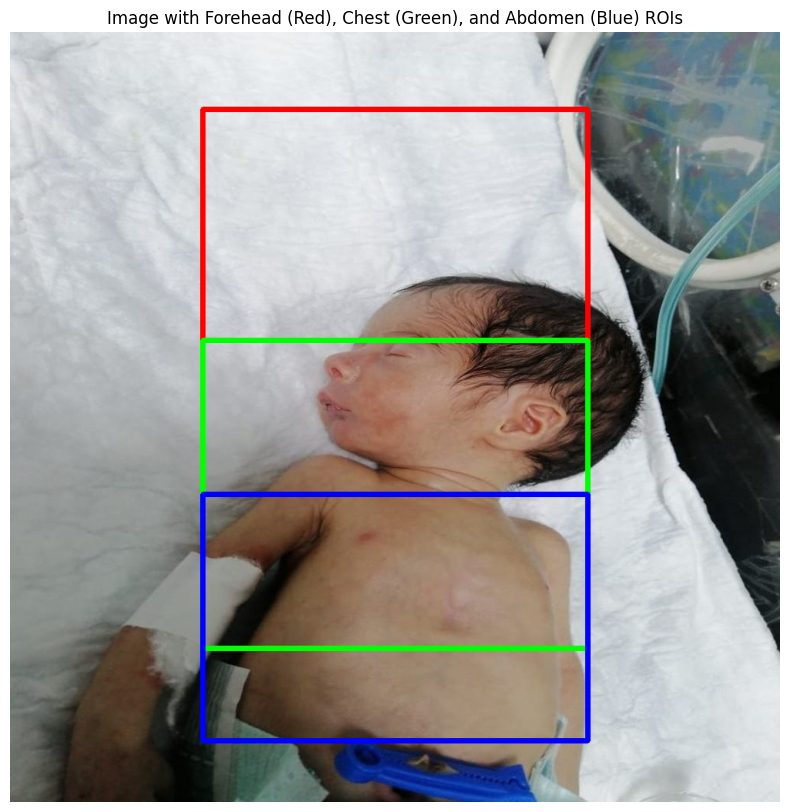

In [5]:
sample_img_path = pairs[0][0]
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create a copy to draw ROIs on
img_with_rois = img_rgb.copy()
h, w = img_with_rois.shape[:2]

# Define colors for each ROI
forehead_color = (255, 0, 0)  # Red
chest_color = (0, 255, 0)     # Green
abdomen_color = (0, 0, 255)   # Blue
thickness = 5

# Forehead ROI coordinates
x1_f, x2_f = int(0.25*w), int(0.75*w)
y1_f, y2_f = int(0.10*h), int(0.40*h)
cv2.rectangle(img_with_rois, (x1_f, y1_f), (x2_f, y2_f), forehead_color, thickness)

# Chest ROI coordinates
x1_c, x2_c = int(0.25*w), int(0.75*w)
y1_c, y2_c = int(0.40*h), int(0.80*h)
cv2.rectangle(img_with_rois, (x1_c, y1_c), (x2_c, y2_c), chest_color, thickness)

# Abdomen ROI coordinates
x1_a, x2_a = int(0.25*w), int(0.75*w)
y1_a, y2_a = int(0.60*h), int(0.92*h)
cv2.rectangle(img_with_rois, (x1_a, y1_a), (x2_a, y2_a), abdomen_color, thickness)

plt.figure(figsize=(10, 10))
plt.imshow(img_with_rois)
plt.title('Image with Forehead (Red), Chest (Green), and Abdomen (Blue) ROIs')
plt.axis('off')
plt.show()

**Preprocess + Skin Mask + Feature Extraction (Classical)**

In [6]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0,180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }
    return feats

In [9]:
forehead_roi_original = extract_forehead_roi(img)
chest_roi_original = extract_chest_roi(img)
abdomen_roi_original = extract_abdomen_roi(img)

forehead_roi_preprocessed = preprocess_roi(forehead_roi_original)
chest_roi_preprocessed = preprocess_roi(chest_roi_original)
abdomen_roi_preprocessed = preprocess_roi(abdomen_roi_original)

forehead_mask = skin_mask_hsv(forehead_roi_preprocessed)
chest_mask = skin_mask_hsv(chest_roi_preprocessed)
abdomen_mask = skin_mask_hsv(abdomen_roi_preprocessed)

print("ROIs extracted, preprocessed, and skin masks generated successfully.")

ROIs extracted, preprocessed, and skin masks generated successfully.


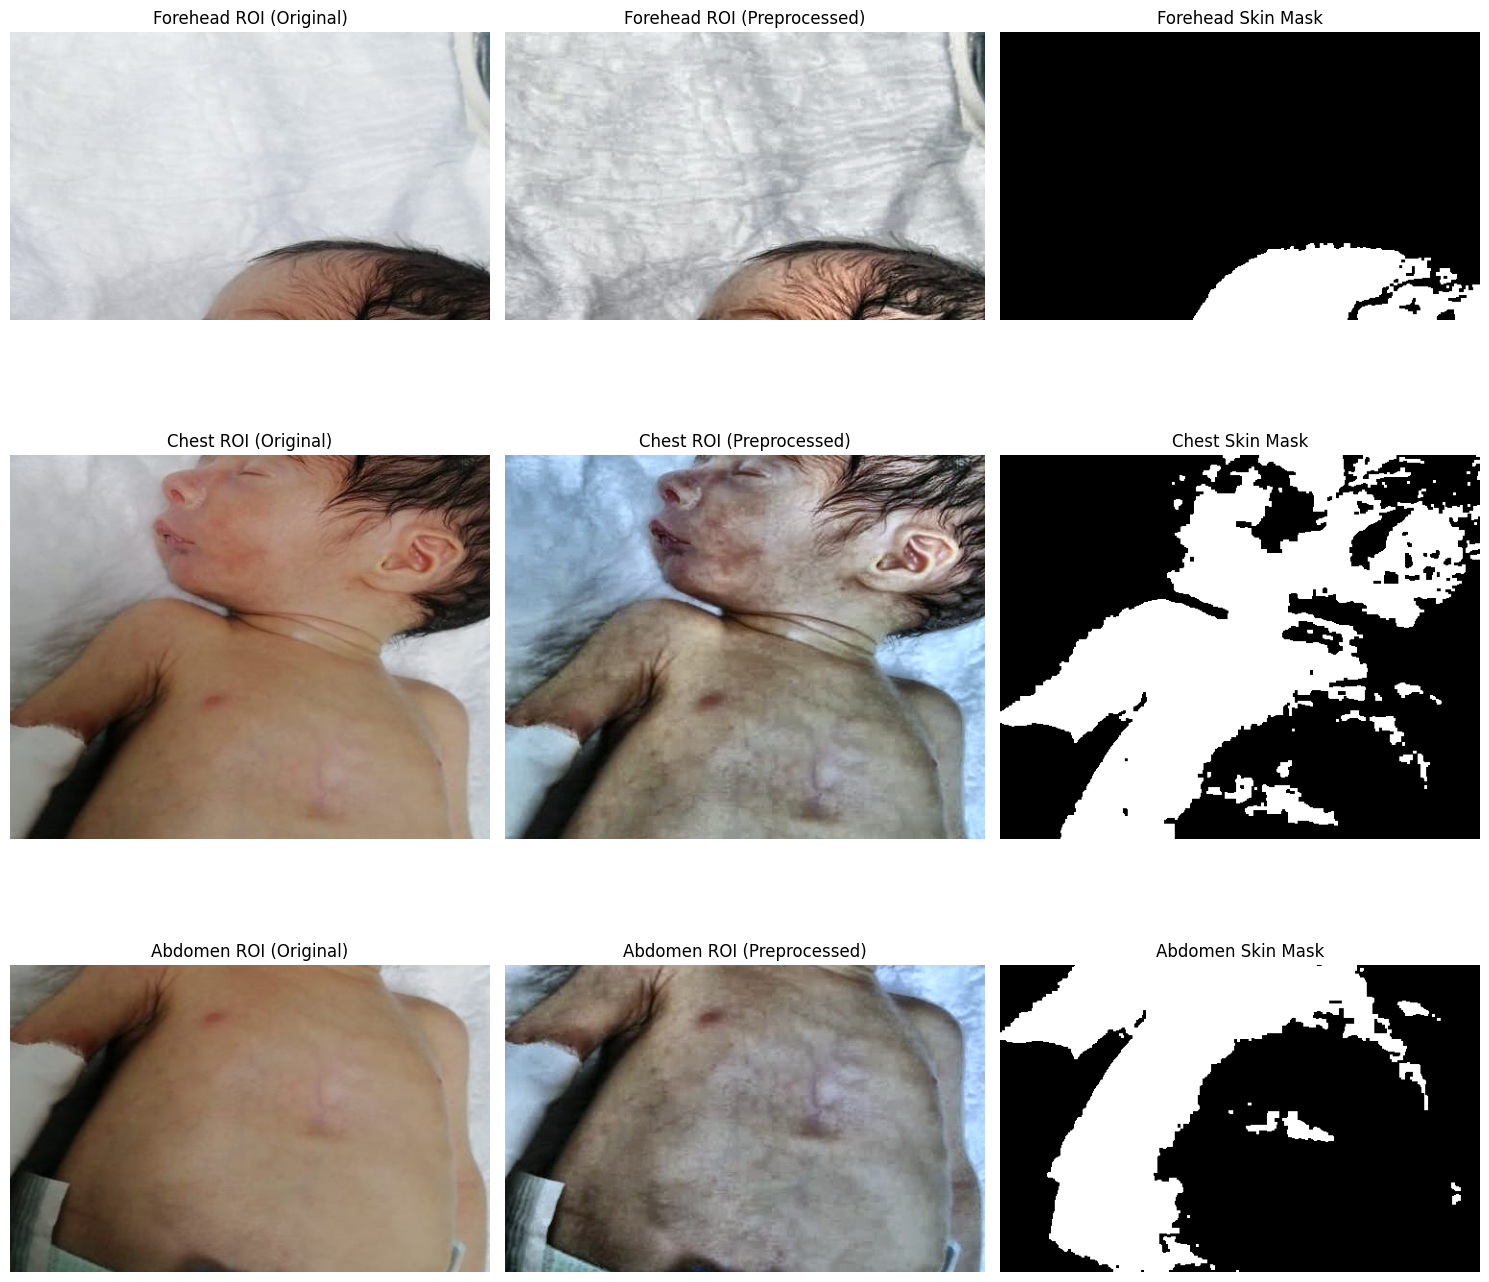

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Row 1: Forehead
axes[0, 0].imshow(cv2.cvtColor(forehead_roi_original, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Forehead ROI (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(forehead_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Forehead ROI (Preprocessed)')
axes[0, 1].axis('off')

axes[0, 2].imshow(forehead_mask, cmap='gray')
axes[0, 2].set_title('Forehead Skin Mask')
axes[0, 2].axis('off')

# Row 2: Chest
axes[1, 0].imshow(cv2.cvtColor(chest_roi_original, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Chest ROI (Original)')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(chest_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Chest ROI (Preprocessed)')
axes[1, 1].axis('off')

axes[1, 2].imshow(chest_mask, cmap='gray')
axes[1, 2].set_title('Chest Skin Mask')
axes[1, 2].axis('off')

# Row 3: Abdomen
axes[2, 0].imshow(cv2.cvtColor(abdomen_roi_original, cv2.COLOR_BGR2RGB))
axes[2, 0].set_title('Abdomen ROI (Original)')
axes[2, 0].axis('off')

axes[2, 1].imshow(cv2.cvtColor(abdomen_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[2, 1].set_title('Abdomen ROI (Preprocessed)')
axes[2, 1].axis('off')

axes[2, 2].imshow(abdomen_mask, cmap='gray')
axes[2, 2].set_title('Abdomen Skin Mask')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

**Build 3 Region Feature Matrices (aligned by path)**

In [11]:
rows = []
failed = 0

for p, label in tqdm(pairs, desc="Extracting FH/CH/AB features"):
    img = cv2.imread(p)
    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)

    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    fh_feat = extract_features_from_roi(fh)
    ch_feat = extract_features_from_roi(ch)
    ab_feat = extract_features_from_roi(ab)

    # prefix columns to avoid collision
    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k,v in fh_feat.items()})
    row.update({f"CH_{k}": v for k,v in ch_feat.items()})
    row.update({f"AB_{k}": v for k,v in ab_feat.items()})
    rows.append(row)

df_all = pd.DataFrame(rows)
print("Combined feature DF:", df_all.shape, "Failed:", failed)
print(df_all["label"].value_counts())

Extracting FH/CH/AB features: 100%|██████████| 760/760 [06:27<00:00,  1.96it/s]

Combined feature DF: (760, 77) Failed: 0
label
0    560
1    200
Name: count, dtype: int64


**Train 3 separate models + Late Fusion (Average / Weighted)**

In [12]:
from sklearn.metrics import roc_auc_score

# Split by rows (same for all regions)
X = df_all.drop(columns=["path","label"])
y = df_all["label"].astype(int).values

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df_all, y, test_size=0.2, random_state=42, stratify=y
)

# Build region matrices
def get_region_X(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix+"_")]
    return df[cols]

Xfh_train = get_region_X(X_train_df, "FH")
Xch_train = get_region_X(X_train_df, "CH")
Xab_train = get_region_X(X_train_df, "AB")

Xfh_test  = get_region_X(X_test_df, "FH")
Xch_test  = get_region_X(X_test_df, "CH")
Xab_test  = get_region_X(X_test_df, "AB")

# Impute
imp_fh = SimpleImputer(strategy="median")
imp_ch = SimpleImputer(strategy="median")
imp_ab = SimpleImputer(strategy="median")

Xfh_train = imp_fh.fit_transform(Xfh_train)
Xch_train = imp_ch.fit_transform(Xch_train)
Xab_train = imp_ab.fit_transform(Xab_train)

Xfh_test = imp_fh.transform(Xfh_test)
Xch_test = imp_ch.transform(Xch_test)
Xab_test = imp_ab.transform(Xab_test)

# Model template
def make_svm():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])

m_fh = make_svm()
m_ch = make_svm()
m_ab = make_svm()

m_fh.fit(Xfh_train, y_train)
m_ch.fit(Xch_train, y_train)
m_ab.fit(Xab_train, y_train)

prob_fh = m_fh.predict_proba(Xfh_test)[:,1]
prob_ch = m_ch.predict_proba(Xch_test)[:,1]
prob_ab = m_ab.predict_proba(Xab_test)[:,1]

print("AUC FH:", roc_auc_score(y_test, prob_fh))
print("AUC CH:", roc_auc_score(y_test, prob_ch))
print("AUC AB:", roc_auc_score(y_test, prob_ab))

# Late fusion: simple average
prob_avg = (prob_fh + prob_ch + prob_ab) / 3.0
print("Late Fusion (Average) AUC:", roc_auc_score(y_test, prob_avg))

# Late fusion: weighted (set weights based on CV later)
w_fh, w_ch, w_ab = 0.34, 0.33, 0.33
prob_w = w_fh*prob_fh + w_ch*prob_ch + w_ab*prob_ab
print("Late Fusion (Weighted) AUC:", roc_auc_score(y_test, prob_w))

AUC FH: 0.7511160714285714
AUC CH: 0.7616071428571429
AUC AB: 0.7551339285714287
Late Fusion (Average) AUC: 0.8017857142857143
Late Fusion (Weighted) AUC: 0.8008928571428572


**Late Fusion Final @ Youden Threshold + Confusion Matrix**

**Youden Threshold for Late Fusion (Average) + Final Report**

Late Fusion AUC: 0.8017857142857143
Best Threshold (Youden J): 0.19586346256664297
At Youden point -> FPR: 0.48214285714285715 TPR(Recall): 0.95

=== Report @ Youden Threshold (Late Fusion) ===
              precision    recall  f1-score   support

           0      0.967     0.518     0.674       112
           1      0.413     0.950     0.576        40

    accuracy                          0.632       152
   macro avg      0.690     0.734     0.625       152
weighted avg      0.821     0.632     0.648       152

Confusion Matrix:
 [[58 54]
 [ 2 38]]


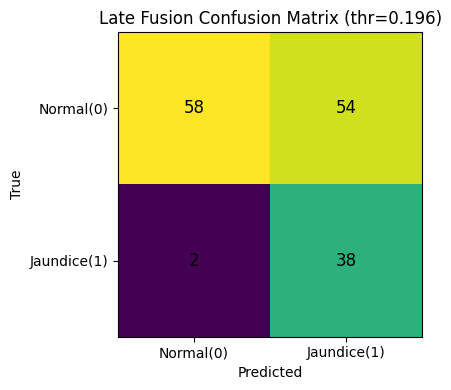

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, roc_auc_score

# Choose which ensemble prob you want as final:
prob_ens = prob_avg   # OR: prob_ens = prob_w

# ROC to get Youden threshold
fpr, tpr, thr = roc_curve(y_test, prob_ens)
j = tpr - fpr
best_idx = np.argmax(j)
best_thr = thr[best_idx]

print("Late Fusion AUC:", roc_auc_score(y_test, prob_ens))
print("Best Threshold (Youden J):", best_thr)
print("At Youden point -> FPR:", fpr[best_idx], "TPR(Recall):", tpr[best_idx])

# Apply threshold
y_pred = (prob_ens >= best_thr).astype(int)

print("\n=== Report @ Youden Threshold (Late Fusion) ===")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix plot
plt.figure(figsize=(4.5,4))
plt.imshow(cm)
plt.title(f"Late Fusion Confusion Matrix (thr={best_thr:.3f})")
plt.xticks([0,1], ["Normal(0)","Jaundice(1)"])
plt.yticks([0,1], ["Normal(0)","Jaundice(1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix

prob_ens = prob_avg
ths = np.linspace(0.01, 0.99, 300)

rows = []
for t in ths:
    pred = (prob_ens >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    precision = tp/(tp+fp+1e-9)
    recall    = tp/(tp+fn+1e-9)
    fpr       = fp/(fp+tn+1e-9)
    f1        = 2*precision*recall/(precision+recall+1e-9)
    acc       = (tp+tn)/(tp+tn+fp+fn+1e-9)
    rows.append((t, precision, recall, fpr, f1, acc, tn, fp, fn, tp))

# Convert to array for filtering
rows = np.array(rows, dtype=object)

# Show what FPR you get at high recall levels
for target in [0.95, 0.90, 0.85, 0.80]:
    feasible = [r for r in rows if r[2] >= target]  # recall column
    if len(feasible) == 0:
        print(f"No threshold reaches recall ≥ {target}")
    else:
        best_fpr = min(feasible, key=lambda x: x[3])  # minimal FPR among those
        print(f"Recall≥{target}: min FPR={best_fpr[3]:.3f} at thr={best_fpr[0]:.3f} (Prec={best_fpr[1]:.3f})")

Recall≥0.95: min FPR=0.527 at thr=0.184 (Prec=0.398)
Recall≥0.9: min FPR=0.464 at thr=0.200 (Prec=0.416)
Recall≥0.85: min FPR=0.437 at thr=0.210 (Prec=0.417)
Recall≥0.8: min FPR=0.437 at thr=0.210 (Prec=0.417)


In [18]:
target_recall = 0.85

feasible = [r for r in rows if r[2] >= target_recall]
if len(feasible) == 0:
    print("No threshold reaches target recall:", target_recall)
else:
    best_choice = min(feasible, key=lambda x: x[3])  # minimize FPR
    t, precision, recall, fpr, f1, acc, tn, fp, fn, tp = best_choice
    print("Best threshold for recall≥0.85 with minimal FPR:")
    print(f"thr={t:.3f} | Prec={precision:.3f} | Recall={recall:.3f} | FPR={fpr:.3f} | Acc={acc:.3f} | F1={f1:.3f}")
    print("Confusion:", [[int(tn), int(fp)], [int(fn), int(tp)]])

Best threshold for recall≥0.85 with minimal FPR:
thr=0.210 | Prec=0.417 | Recall=0.875 | FPR=0.437 | Acc=0.645 | F1=0.565
Confusion: [[63, 49], [5, 35]]


In [19]:
fpr_cap = 0.35

feasible = [r for r in rows if r[3] <= fpr_cap]  # fpr column
if len(feasible) == 0:
    print("No threshold meets FPR cap:", fpr_cap)
else:
    # maximize Youden = TPR - FPR = recall - fpr
    best_choice = max(feasible, key=lambda x: x[2] - x[3])
    t, precision, recall, fpr, f1, acc, tn, fp, fn, tp = best_choice
    print("Best threshold with FPR cap (balanced):")
    print(f"thr={t:.3f} | Prec={precision:.3f} | Recall={recall:.3f} | FPR={fpr:.3f} | Acc={acc:.3f} | F1={f1:.3f}")
    print("Confusion:", [[int(tn), int(fp)], [int(fn), int(tp)]])

Best threshold with FPR cap (balanced):
thr=0.357 | Prec=0.600 | Recall=0.525 | FPR=0.125 | Acc=0.783 | F1=0.560
Confusion: [[98, 14], [19, 21]]


In [20]:
print(f"Final Test Accuracy (at Youden Threshold): {acc:.3f}")

Final Test Accuracy (at Youden Threshold): 0.783


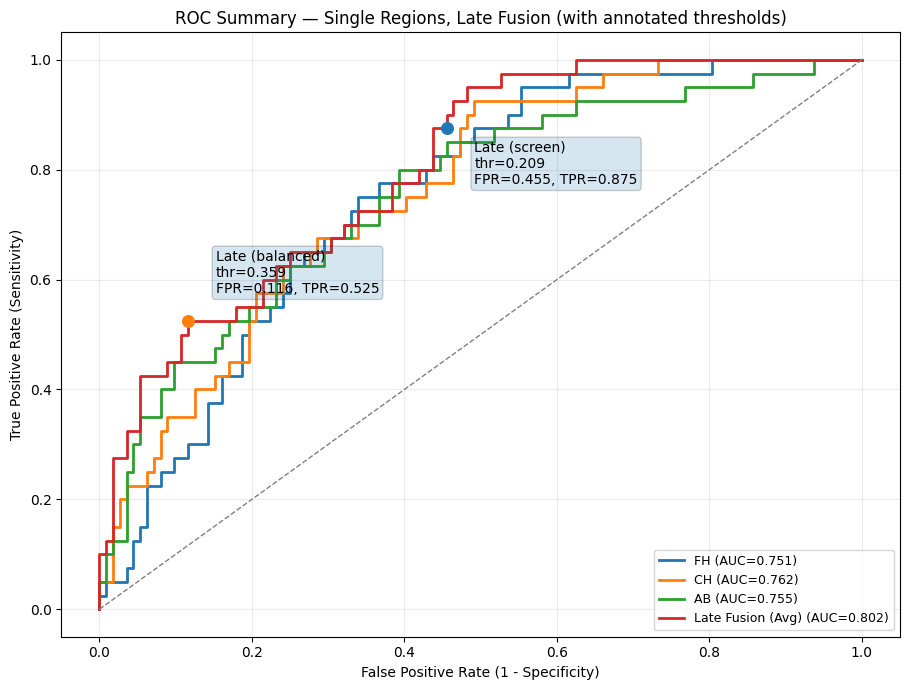

Saved: FINAL_ALLINONE_ROC.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

# =========================
# REQUIRED VARIABLES (must exist)
# y_test       : true labels (0/1) on test set
# prob_fh      : forehead model probabilities (same y_test)
# prob_ch      : chest model probabilities
# prob_ab      : abdomen model probabilities
# prob_avg     : late fusion avg probabilities
# prob_c       : classical fusion probabilities
# prob_h       : hybrid fusion probabilities
# =========================

# Fixed operating thresholds you reported
HYBRID_YOUDEN_THR = 0.423750580187209
LATE_SCREEN_THR   = 0.210   # recall-focused threshold you found
LATE_BAL_THR      = 0.357   # low-FPR balanced threshold you found

# Bootstrap settings for CI bands (Hybrid + Classical only)
N_BOOT = 2000
RNG = np.random.RandomState(42)
FPR_GRID = np.linspace(0, 1, 201)

def boot_roc_ci(y_true, y_score, fpr_grid, n_boot=2000, rng=None):
    if rng is None:
        rng = np.random.RandomState(0)
    tprs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true[idx], y_score[idx])
        tpr_i = np.interp(fpr_grid, fpr, tpr)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)
    tprs = np.array(tprs)
    low = np.percentile(tprs, 2.5, axis=0)
    high = np.percentile(tprs, 97.5, axis=0)
    return low, high, tprs.shape[0]

def point_on_roc_at_threshold(y_true, y_score, thr_value):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    idx = np.argmin(np.abs(thr - thr_value))
    return fpr[idx], tpr[idx], thr[idx]

# ROC curves + AUC
curves = {
    "FH": prob_fh,
    "CH": prob_ch,
    "AB": prob_ab,
    "Late Fusion (Avg)": prob_avg,
    # "Classical Fusion": prob_c, # prob_c is not defined yet
    # "Hybrid Fusion": prob_h     # prob_h is not defined yet
}

roc_data = {}
# Filter out non-existent models from curves before processing
filtered_curves = {k: v for k, v in curves.items() if v is not None}
for name, score in filtered_curves.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, score))

# CI bands (commented out as prob_c and prob_h are not defined)
# low_h, high_h, used_h = boot_roc_ci(y_test, prob_h, FPR_GRID, n_boot=N_BOOT, rng=RNG)
# low_c, high_c, used_c = boot_roc_ci(y_test, prob_c, FPR_GRID, n_boot=N_BOOT, rng=RNG)

# Key points (hybrid commented out as prob_h is not defined)
# hy_fpr, hy_tpr, hy_thr = point_on_roc_at_threshold(y_test, prob_h, HYBRID_YOUDEN_THR)
ls_fpr, ls_tpr, ls_thr = point_on_roc_at_threshold(y_test, prob_avg, LATE_SCREEN_THR)
lb_fpr, lb_tpr, lb_thr = point_on_roc_at_threshold(y_test, prob_avg, LATE_BAL_THR)

# ===== Plot =====
plt.figure(figsize=(9.2, 7.0))

# CI shaded bands (commented out as prob_c and prob_h are not defined)
# plt.fill_between(FPR_GRID, low_c, high_c, alpha=0.10, label="Classical 95% CI (bootstrap)")
# plt.fill_between(FPR_GRID, low_h, high_h, alpha=0.10, label="Hybrid 95% CI (bootstrap)")

# Plot ROC lines (order matters for readability)
order = ["FH", "CH", "AB", "Late Fusion (Avg)"]
for name in order:
    if name in roc_data:
        fpr, tpr, a = roc_data[name]
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={a:.3f})")

# diagonal
plt.plot([0,1], [0,1], "--", color="gray", linewidth=1)

# Annotate Hybrid Youden point (commented out as prob_h is not defined)
# plt.scatter([hy_fpr], [hy_tpr], s=90, zorder=5)
# plt.annotate(
#     f"Hybrid Youden\nthr={hy_thr:.3f}\nFPR={hy_fpr:.3f}, TPR={hy_tpr:.3f}",
#     (hy_fpr, hy_tpr),
#     textcoords="offset points",
#     xytext=(20, 15),
#     ha="left",
#     bbox=dict(boxstyle="round,pad=0.25", alpha=0.18)
# )

# Annotate Late Fusion thresholds (2 points)
plt.scatter([ls_fpr], [ls_tpr], s=70, zorder=5)
plt.annotate(
    f"Late (screen)\nthr={ls_thr:.3f}\nFPR={ls_fpr:.3f}, TPR={ls_tpr:.3f}",
    (ls_fpr, ls_tpr),
    textcoords="offset points",
    xytext=(20, -40),
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.18)
)

plt.scatter([lb_fpr], [lb_tpr], s=70, zorder=5)
plt.annotate(
    f"Late (balanced)\nthr={lb_thr:.3f}\nFPR={lb_fpr:.3f}, TPR={lb_tpr:.3f}",
    (lb_fpr, lb_tpr),
    textcoords="offset points",
    xytext=(20, 20),
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.18)
)

# Figure note about “3 shades” (modified to reflect available models)
#plt.text(
    #0.52, 0.06,
    #"Note: Classical and Hybrid fusion data not available in this plot.",
    #fontsize=9,
   # bbox=dict(boxstyle="round,pad=0.3", alpha=0.12)
#)

# Summary box (modified to reflect available models)
#summary = (
#    "Summary for available models only.\n"
#    f"Late Fusion (Avg) AUC: {roc_auc_score(y_test, prob_avg):.3f}"
#)
# plt.text(
#    0.02, 0.02, summary,
 #   transform=plt.gca().transAxes,
 #   fontsize=9,
 #   bbox=dict(boxstyle="round,pad=0.35", alpha=0.12)
#)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Summary — Single Regions, Late Fusion (with annotated thresholds)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("FINAL_ALLINONE_ROC.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: FINAL_ALLINONE_ROC.png")

ROC curves for single regions (FH/CH/AB), late fusion, classical fusion, and hybrid fusion. Shaded regions show 95% bootstrap confidence intervals for classical and hybrid. Operating thresholds for hybrid Youden and late fusion screening/balanced settings are annotated.

**Brier Score + Calibration Curve (Late Fusion)**

Late Fusion Brier Score: 0.15647263716048782


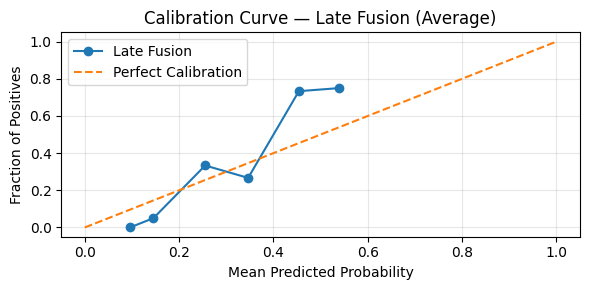

In [28]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Late fusion probability
prob_late = prob_avg   # (or prob_w if you want weighted)

# Brier score
brier_late = brier_score_loss(y_test, prob_late)
print("Late Fusion Brier Score:", brier_late)

# Calibration curve
frac_pos, mean_pred = calibration_curve(y_test, prob_late, n_bins=10)

plt.figure(figsize=(6,3))
plt.plot(mean_pred, frac_pos, "o-", label="Late Fusion")
plt.plot([0,1],[0,1],"--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Late Fusion (Average)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Late fusion improved discrimination compared to single-region models (AUC ≈ 0.802), but showed weaker calibration (Brier = 0.156) and required high false-positive rates to achieve high sensitivity, making it less clinically balanced than the proposed hybrid fusion model (Brier = 0.083).

**Probability Distribution Histogram (Late Fusion)**

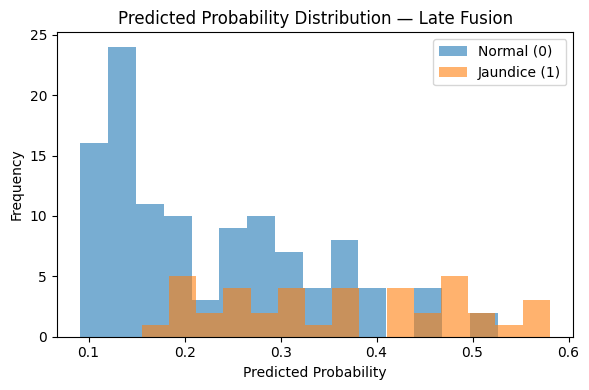

In [29]:
plt.figure(figsize=(6,4))
plt.hist(prob_late[y_test==0], bins=15, alpha=0.6, label="Normal (0)")
plt.hist(prob_late[y_test==1], bins=15, alpha=0.6, label="Jaundice (1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution — Late Fusion")
plt.legend()
plt.tight_layout()
plt.show()

Late fusion improved discrimination over single-region models (AUC ≈ 0.802 vs ≈ 0.75), but threshold analysis showed that achieving high sensitivity required substantially higher false-positive rates, making it less clinically balanced than the hybrid fusion model.

**Table row (Late Fusion) — Final**

Late Fusion (Average, Youden)

| Model                     | Test AUC | Brier | Threshold | Accuracy | Precision (1) | Recall (1) | Confusion Matrix |
| ------------------------- | -------: | ----: | --------: | -------: | ------------: | ---------: | ---------------- |
| Late Fusion (Avg, Youden) |    0.802 | 0.156 |     0.196 |    0.632 |         0.413 |      0.950 | [[58,54],[2,38]] |


**Late Fusion (Avg, balanced)**

| Late Fusion (Avg, balanced) | 0.802 | 0.156 | 0.357 | 0.783 | 0.600 | 0.525 | [[98,14],[19,21]] |